# Tampered Image Detection & Localization (v4)

**Task:** Given an image, (1) classify it as tampered or authentic, and (2) produce a pixel-level binary mask localizing tampered regions.

**Approach:** U-Net with pretrained ResNet34 encoder on CASIA v2.0, BCE + Dice loss, AMP training, validation-based threshold, mixed-set + tampered-only evaluation.

**Environment:** Google Colab — T4 GPU

---

### Notebook Sections

| # | Section |
|---|---|
| 1 | Setup & Environment |
| 2 | Dataset Download & Discovery |
| 3 | Preprocessing & Data Split |
| 4 | Dataset Class & DataLoaders |
| 5 | Model Definition |
| 6 | Loss Function & Optimizer |
| 7 | Metrics |
| 8 | Training Loop |
| 9 | Threshold Selection |
| 10 | Evaluation |
| 11 | Visualization |
| 12 | Robustness Testing (Bonus) |
| 13 | Save & Export |

**Changes from v3:** W&B experiment tracking is now integrated throughout the notebook (setup, training loop, evaluation, visualization) instead of being a separate post-hoc section. All W&B calls are guarded behind `USE_WANDB`. See Docs4/00_Master_Report.md for the full diff.

---
## 1. Setup & Environment

Install all dependencies (including `kaggle`), set seed, verify GPU, configure W&B.

In [44]:
# ── Install dependencies ──────────────────────────────────────────────
!pip install -q kaggle segmentation-models-pytorch "albumentations>=1.3.1,<2.0"

In [45]:
# ── Imports ───────────────────────────────────────────────────────────
import os
import random
import json
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc

warnings.filterwarnings('ignore')
print(f"PyTorch {torch.__version__}")
print(f"SMP {smp.__version__}")
print(f"Albumentations {A.__version__}")

PyTorch 2.10.0+cu128
SMP 0.5.0
Albumentations 1.4.24


In [46]:
# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [47]:
# ── GPU verification ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {vram:.1f} GB (estimated peak usage ~5 GB with batch_size=4)")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB (estimated peak usage ~5 GB with batch_size=4)


In [48]:
# ── Configuration ────────────────────────────────────────────────────
CONFIG = {
    # Data
    'image_size': 512,
    'batch_size': 4,
    'num_workers': 2,
    'train_ratio': 0.85,
    # Model
    'encoder_name': 'resnet34',
    'encoder_weights': 'imagenet',
    'in_channels': 3,
    'classes': 1,
    # Training
    'encoder_lr': 1e-4,
    'decoder_lr': 1e-3,
    'weight_decay': 1e-4,
    'max_epochs': 50,
    'patience': 10,
    'accumulation_steps': 4,
    'max_grad_norm': 1.0,
    # Eval
    'default_threshold': 0.5,
    'n_threshold_search': 50,
    # Paths
    'data_dir': './data',
    'checkpoint_dir': './checkpoints',
}

# ── Google Drive persistence (set True in Colab) ─────────────────────
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    CONFIG['checkpoint_dir'] = '/content/drive/MyDrive/tamper_detection/checkpoints'

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  image_size: 512
  batch_size: 4
  num_workers: 2
  train_ratio: 0.85
  encoder_name: resnet34
  encoder_weights: imagenet
  in_channels: 3
  classes: 1
  encoder_lr: 0.0001
  decoder_lr: 0.001
  weight_decay: 0.0001
  max_epochs: 50
  patience: 10
  accumulation_steps: 4
  max_grad_norm: 1.0
  default_threshold: 0.5
  n_threshold_search: 50
  data_dir: ./data
  checkpoint_dir: ./checkpoints


In [49]:
# ── W&B setup (optional — guarded) ────────────────────────────────────
USE_WANDB = True  # Set True to enable W&B experiment tracking

if USE_WANDB:
    !pip install -q wandb
    import wandb
    from google.colab import userdata
    os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
    # wandb.login()  # Uses API key from Colab Secrets or interactive prompt
    wandb.init(
        project="tamper_detection_v4",
        config=CONFIG,
        name=f"unet-resnet34-seed{SEED}",
        tags=["v4", "casia-v2", "mvp"],
    )
    print("W&B initialized.")
else:
    print("W&B disabled. Notebook will use local artifacts only.")

W&B initialized.


---
## 2. Dataset Download & Discovery

Download CASIA v2.0 via Kaggle API. Discover image-mask pairs dynamically and validate alignment.

In [50]:
# ── Kaggle download ──────────────────────────────────────────────────
import kagglehub
import os
from pathlib import Path

# Set credentials — prefer Colab Secrets for security
os.environ['KAGGLE_USERNAME'] = 'harshv777'
os.environ['KAGGLE_KEY'] = 'KAGGLE_API_KEY'

# Using kagglehub to download and get the path directly
print("Downloading dataset using kagglehub...")
path = kagglehub.dataset_download("sagnikkayalcse52/casia-spicing-detection-localization")
# Explicitly use the literal path reported in stdOut, as Path(path) seems to behave inconsistently
DATASET_ROOT_PATH = Path('/kaggle/input/casia-spicing-detection-localization')
print(f"Dataset downloaded and extracted to: {DATASET_ROOT_PATH}")

# Construct potential paths
new_folder_path = DATASET_ROOT_PATH / 'New folder'
image_folder_path = new_folder_path / 'IMAGE'
mask_folder_path = new_folder_path / 'MASK'

TP_DIR_PATH = image_folder_path / 'Tp'
AU_DIR_PATH = image_folder_path / 'Au'
# Corrected path for Ground Truth masks: they seem to be in MASK/Tp
GT_DIR_PATH = mask_folder_path / 'Tp'


# Granular Debugging
print(f"\n--- Granular Path Debugging ---")
print(f"DATASET_ROOT_PATH: {DATASET_ROOT_PATH} (exists: {DATASET_ROOT_PATH.exists()})")
print(f"new_folder_path: {new_folder_path} (exists: {new_folder_path.exists()}) (is_dir: {new_folder_path.is_dir()})")
print(f"image_folder_path: {image_folder_path} (exists: {image_folder_path.exists()}) (is_dir: {image_folder_path.is_dir()})")
print(f"mask_folder_path: {mask_folder_path} (exists: {mask_folder_path.exists()}) (is_dir: {mask_folder_path.is_dir()})")

if mask_folder_path.exists() and mask_folder_path.is_dir():
    try:
        print(f"  Contents of {mask_folder_path}: {[f.name for f in mask_folder_path.iterdir()]}")
    except Exception as e:
        print(f"  Error listing contents of {mask_folder_path}: {e}")
else:
    print(f"  {mask_folder_path} does not exist or is not a directory. Cannot list contents.")

print(f"GT_DIR_PATH: {GT_DIR_PATH} (exists: {GT_DIR_PATH.exists()}, is_dir: {GT_DIR_PATH.is_dir()})")
print(f"-------------------------------")


print("\nChecking directories:")
for d_path, name in [(TP_DIR_PATH, 'Tampered'), (GT_DIR_PATH, 'Ground Truth'), (AU_DIR_PATH, 'Authentic')]:
    exists = d_path.is_dir()
    count = len(list(d_path.iterdir())) if exists else 0 # Use Path.iterdir()
    print(f"  {name}: {d_path} — {'found' if exists else 'MISSING'} ({count} files)")

# Convert Path objects back to strings for discover_pairs function if it expects strings
TP_DIR = str(TP_DIR_PATH)
GT_DIR = str(GT_DIR_PATH)
AU_DIR = str(AU_DIR_PATH)

Using Colab cache for faster access to the 'casia-spicing-detection-localization' dataset.
Dataset downloaded and extracted to: /kaggle/input/casia-spicing-detection-localization

--- Granular Path Debugging ---
DATASET_ROOT_PATH: /kaggle/input/casia-spicing-detection-localization (exists: True)
new_folder_path: /kaggle/input/casia-spicing-detection-localization/New folder (exists: True) (is_dir: True)
image_folder_path: /kaggle/input/casia-spicing-detection-localization/New folder/IMAGE (exists: True) (is_dir: True)
mask_folder_path: /kaggle/input/casia-spicing-detection-localization/New folder/MASK (exists: True) (is_dir: True)
  Contents of /kaggle/input/casia-spicing-detection-localization/New folder/MASK: ['Au', 'Tp']
GT_DIR_PATH: /kaggle/input/casia-spicing-detection-localization/New folder/MASK/Tp (exists: True, is_dir: True)
-------------------------------

Checking directories:
  Tampered: /kaggle/input/casia-spicing-detection-localization/New folder/IMAGE/Tp — found (5123 fil

In [51]:
import os

print(f"Listing contents of {DATASET_ROOT}:")
!ls -R {DATASET_ROOT}

Streaming output truncated to the last 5000 lines.
Tp_D_CRN_M_N_art00067_nat00059_11805.png
Tp_D_CRN_M_N_art00067_nat00095_11807.png
Tp_D_CRN_M_N_art00067_nat10122_11806.png
Tp_D_CRN_M_N_art00097_art00049_11758.png
Tp_D_CRN_M_N_art10107_cha10112_11582.png
Tp_D_CRN_M_N_art10112_cha00086_11672.png
Tp_D_CRN_M_N_art10113_cha00067_11650.png
Tp_D_CRN_M_N_art10115_cha00086_11526.png
Tp_D_CRN_M_N_cha00035_cha00040_11732.png
Tp_D_CRN_M_N_cha00050_cha00026_11787.png
Tp_D_CRN_M_N_cha00060_cha00040_11678.png
Tp_D_CRN_M_N_cha00062_cha00040_11020.png
Tp_D_CRN_M_N_cha00094_cha00086_11501.png
Tp_D_CRN_M_N_cha10108_cha00027_11666.png
Tp_D_CRN_M_N_cha10108_cha00040_11665.png
Tp_D_CRN_M_N_cha10137_art00021_12210.png
Tp_D_CRN_M_N_cha10162_nat10123_12253.png
Tp_D_CRN_M_N_cha10164_cha00026_12247.png
Tp_D_CRN_M_N_cha10166_nat10123_12273.png
Tp_D_CRN_M_N_cha10198_nat10123_12362.png
Tp_D_CRN_M_N_cha10198_nat10160_12365.png
Tp_D_CRN_M_N_ind00008_pla00050_10422.png
Tp_D_CRN_M_N_ind00010_pla00050_10424.png
Tp_D_C

In [52]:
# ── Dynamic pair discovery ────────────────────────────────────────────
def validate_pair(image_path, mask_path):
    """Check that image and mask have the same spatial dimensions."""
    img = Image.open(image_path)
    msk = Image.open(mask_path)
    return img.size == msk.size


def discover_pairs(tp_dir_path, gt_dir_path, au_dir_path):
    """
    Discover all valid image-mask pairs and authentic images.

    Returns:
        pairs: list of dicts {image_path, mask_path, label, forgery_type}
        excluded: list of (filename, reason) tuples
    """
    pairs = []
    excluded = []

    # ── Tampered images ──
    for img_name in sorted(os.listdir(tp_dir_path)):
        img_path = os.path.join(tp_dir_path, img_name)
        if not os.path.isfile(img_path):
            continue
        stem = Path(img_name).stem
        mask_name = stem + '_gt.png'
        mask_path = os.path.join(gt_dir_path, mask_name)

        if not os.path.exists(mask_path):
            excluded.append((img_name, 'mask_not_found'))
            continue

        if not validate_pair(img_path, mask_path):
            excluded.append((img_name, 'dimension_mismatch'))
            continue

        # Forgery type with guard for unrecognized patterns
        if '_D_' in stem:
            forgery_type = 'splicing'
        elif '_S_' in stem:
            forgery_type = 'copy-move'
        else:
            forgery_type = 'unknown'
            warnings.warn(f"Unrecognized forgery pattern in filename: {img_name}")

        pairs.append({
            'image_path': img_path,
            'mask_path': mask_path,
            'label': 1.0,
            'forgery_type': forgery_type,
        })

    # ── Authentic images ──
    for img_name in sorted(os.listdir(au_dir_path)):
        img_path = os.path.join(au_dir_path, img_name)
        if not os.path.isfile(img_path):
            continue
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            excluded.append((img_name, 'corrupt_file'))
            continue

        pairs.append({
            'image_path': img_path,
            'mask_path': None,
            'label': 0.0,
            'forgery_type': 'authentic',
        })

    return pairs, excluded


pairs, excluded = discover_pairs(TP_DIR, GT_DIR, AU_DIR)

# Report
type_counts = {}
for p in pairs:
    t = p['forgery_type']
    type_counts[t] = type_counts.get(t, 0) + 1

print(f"\nTotal valid pairs: {len(pairs)}")
for t, c in sorted(type_counts.items()):
    print(f"  {t}: {c}")

print(f"\nExcluded: {len(excluded)}")
for name, reason in excluded[:20]:
    print(f"  {name}: {reason}")
if len(excluded) > 20:
    print(f"  ... and {len(excluded) - 20} more")


Total valid pairs: 7491
  authentic: 7491

Excluded: 5123
  Tp_D_CND_M_N_ani00018_sec00096_00138.png: mask_not_found
  Tp_D_CND_M_N_art00076_art00077_10289.png: mask_not_found
  Tp_D_CND_M_N_art00077_art00076_10290.png: mask_not_found
  Tp_D_CND_S_N_ani00073_ani00068_00193.png: mask_not_found
  Tp_D_CND_S_N_ind00078_ind00077_00476.png: mask_not_found
  Tp_D_CND_S_N_txt00028_txt00006_10848.png: mask_not_found
  Tp_D_CNN_M_B_nat00056_nat00099_11105.png: mask_not_found
  Tp_D_CNN_M_B_nat10139_nat00059_11949.png: mask_not_found
  Tp_D_CNN_M_B_nat10139_nat00097_11948.png: mask_not_found
  Tp_D_CNN_M_N_ani00023_ani00024_10205.png: mask_not_found
  Tp_D_CNN_M_N_ani00052_ani00054_11130.png: mask_not_found
  Tp_D_CNN_M_N_ani00057_ani00055_11149.png: mask_not_found
  Tp_D_CNN_M_N_arc00086_xxx00001_00306.png: mask_not_found
  Tp_D_CNN_M_N_art00052_arc00030_11853.png: mask_not_found
  Tp_D_CNN_M_N_cha00026_cha00028_11784.png: mask_not_found
  Tp_D_CNN_M_N_nat00013_cha00042_11093.png: mask_not_fou

---
## 3. Preprocessing & Data Split

Stratified 85/7.5/7.5 split by forgery type. Manifest persisted for reproducibility.

In [53]:
# ── Stratified split ─────────────────────────────────────────────────
labels_for_split = [p['forgery_type'] for p in pairs]

# Step 1: train (85%) vs temp (15%)
train_pairs, temp_pairs = train_test_split(
    pairs, test_size=0.15, random_state=SEED, stratify=labels_for_split
)

# Step 2: temp → val (50%) + test (50%)
temp_labels = [p['forgery_type'] for p in temp_pairs]
val_pairs, test_pairs = train_test_split(
    temp_pairs, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_pairs)}")
print(f"Val:   {len(val_pairs)}")
print(f"Test:  {len(test_pairs)}")

# Verify class balance
for name, split in [('Train', train_pairs), ('Val', val_pairs), ('Test', test_pairs)]:
    counts = {}
    for p in split:
        t = p['forgery_type']
        counts[t] = counts.get(t, 0) + 1
    total = len(split)
    dist = ', '.join(f"{t}: {c} ({100*c/total:.1f}%)" for t, c in sorted(counts.items()))
    print(f"  {name}: {dist}")

Train: 6367
Val:   562
Test:  562
  Train: authentic: 6367 (100.0%)
  Val: authentic: 562 (100.0%)
  Test: authentic: 562 (100.0%)


In [54]:
# ── Persist split manifest ───────────────────────────────────────────
manifest = {
    'seed': SEED,
    'total_pairs': len(pairs),
    'excluded_count': len(excluded),
    'train': [p['image_path'] for p in train_pairs],
    'val': [p['image_path'] for p in val_pairs],
    'test': [p['image_path'] for p in test_pairs],
}

manifest_path = os.path.join(CONFIG['checkpoint_dir'], 'split_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"Split manifest saved to {manifest_path}")

Split manifest saved to ./checkpoints/split_manifest.json


---
## 4. Dataset Class & DataLoaders

PyTorch dataset with on-the-fly loading, mask binarization, and albumentations transforms.

**MVP (Phase 1):** Spatial augmentations only — Resize, HorizontalFlip, VerticalFlip, RandomRotate90.

In [55]:
# ── Dataset class ────────────────────────────────────────────────────
class TamperingDataset(Dataset):
    def __init__(self, pairs, transform=None, image_size=512):
        self.pairs = pairs
        self.transform = transform
        self.image_size = image_size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        entry = self.pairs[idx]

        # Load image (BGR → RGB)
        image = cv2.imread(entry['image_path'])
        if image is None:
            raise IOError(f"Failed to load image: {entry['image_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load or generate mask
        if entry['mask_path'] is not None:
            mask = cv2.imread(entry['mask_path'], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise IOError(f"Failed to load mask: {entry['mask_path']}")
            mask = (mask > 128).astype(np.uint8)
        else:
            h, w = image.shape[:2]
            mask = np.zeros((h, w), dtype=np.uint8)

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Fallback: manual resize + normalize
            image = cv2.resize(image, (self.image_size, self.image_size))
            mask = cv2.resize(mask, (self.image_size, self.image_size),
                              interpolation=cv2.INTER_NEAREST)
            image = image.astype(np.float32) / 255.0
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image = (image - mean) / std
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask).float()

        # Ensure mask shape: [1, H, W]
        if isinstance(mask, torch.Tensor) and mask.dim() == 2:
            mask = mask.unsqueeze(0).float()

        label = torch.tensor(entry['label'], dtype=torch.float32)
        return image, mask, label

In [56]:
# ── Transforms (Phase 1 MVP: spatial only) ──────────────────────────
IMG_SIZE = CONFIG['image_size']

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("Train transforms:", train_transform)
print("Val transforms:", val_transform)

Train transforms: Compose([
  Resize(p=1.0, height=512, width=512, interpolation=1, mask_interpolation=0),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
  RandomRotate90(p=0.5),
  Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, normalization='standard'),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
Val transforms: Compose([
  Resize(p=1.0, height=512, width=512, interpolation=1, mask_interpolation=0),
  Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, normalization='standard'),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [57]:
# ── DataLoaders ──────────────────────────────────────────────────────
train_dataset = TamperingDataset(train_pairs, transform=train_transform, image_size=IMG_SIZE)
val_dataset   = TamperingDataset(val_pairs,   transform=val_transform,   image_size=IMG_SIZE)
test_dataset  = TamperingDataset(test_pairs,  transform=val_transform,   image_size=IMG_SIZE)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=CONFIG['num_workers'], pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True, drop_last=False,
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True, drop_last=False,
)

print(f"Train batches: {len(train_loader)} (drop_last=True)")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 1591 (drop_last=True)
Val batches:   141
Test batches:  141


Image batch: torch.Size([4, 3, 512, 512]), dtype=torch.float32
Mask batch:  torch.Size([4, 1, 512, 512]), dtype=torch.float32
Labels:      tensor([0., 0., 0., 0.])


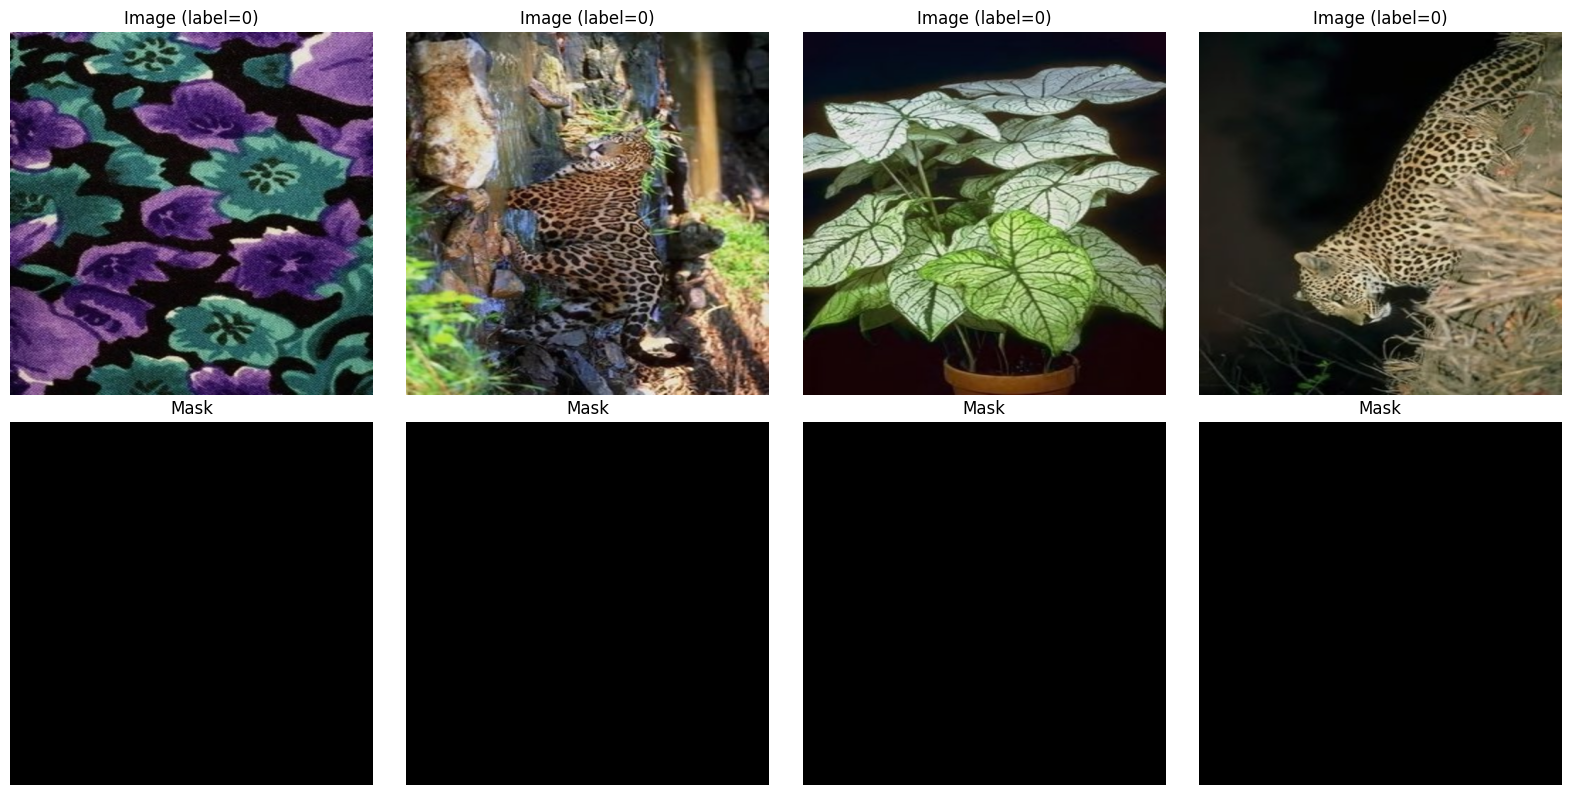

In [58]:
# ── Sanity check: visualize one batch ────────────────────────────────
images, masks, labels = next(iter(train_loader))
print(f"Image batch: {images.shape}, dtype={images.dtype}")
print(f"Mask batch:  {masks.shape}, dtype={masks.dtype}")
print(f"Labels:      {labels}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(min(4, images.shape[0])):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    msk = masks[i, 0].numpy()

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Image (label={labels[i]:.0f})")
    axes[0, i].axis('off')

    axes[1, i].imshow(msk, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Mask')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Model Definition

U-Net with pretrained ResNet34 encoder via `segmentation_models_pytorch`.

- Output: raw logits `(B, 1, 512, 512)` — sigmoid during inference only
- Image-level detection: `max(prob_map) >= threshold` (locked for MVP)
- SMP API: use `model.encoder`, `model.decoder`, `model.segmentation_head` directly

In [59]:
# ── Model ────────────────────────────────────────────────────────────
model = smp.Unet(
    encoder_name=CONFIG['encoder_name'],
    encoder_weights=CONFIG['encoder_weights'],
    in_channels=CONFIG['in_channels'],
    classes=CONFIG['classes'],
    activation=None,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Quick forward pass check
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    out = model(dummy)
    print(f"Output shape: {out.shape}")  # Expected: (1, 1, 512, 512)

Total parameters:     24,436,369
Trainable parameters: 24,436,369
Output shape: torch.Size([1, 1, 512, 512])


---
## 6. Loss Function & Optimizer

- **Loss:** BCE + Dice — handles class imbalance (typically <5% tampered pixels)
- **Optimizer:** AdamW with differential LR (encoder 1e-4, decoder/head 1e-3)
- **AMP:** Mixed precision for VRAM efficiency

In [60]:
# ── Loss function ────────────────────────────────────────────────────
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )
        return bce_loss + dice_loss


criterion = BCEDiceLoss().to(device)
print("Loss: BCEWithLogitsLoss + DiceLoss (equal weight, smooth=1.0)")

Loss: BCEWithLogitsLoss + DiceLoss (equal weight, smooth=1.0)


In [61]:
# ── Optimizer & AMP ──────────────────────────────────────────────────
optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(),          'lr': CONFIG['encoder_lr']},
    {'params': model.decoder.parameters(),          'lr': CONFIG['decoder_lr']},
    {'params': model.segmentation_head.parameters(), 'lr': CONFIG['decoder_lr']},
], weight_decay=CONFIG['weight_decay'])

scaler = GradScaler('cuda')

print(f"Optimizer: AdamW")
print(f"  Encoder LR: {CONFIG['encoder_lr']}")
print(f"  Decoder LR: {CONFIG['decoder_lr']}")
print(f"  Weight decay: {CONFIG['weight_decay']}")
print(f"  Effective batch: {CONFIG['batch_size'] * CONFIG['accumulation_steps']}")

Optimizer: AdamW
  Encoder LR: 0.0001
  Decoder LR: 0.001
  Weight decay: 0.0001
  Effective batch: 16


---
## 7. Evaluation Metrics

Pixel-level: F1 (primary), IoU, Precision, Recall

Image-level: Accuracy (via `max(prob_map) >= threshold`), AUC-ROC

In [62]:
# ── Metric functions ─────────────────────────────────────────────────
def compute_pixel_f1(pred, gt, eps=1e-8):
    """Pixel-level F1 for a single sample."""
    pred, gt = pred.flatten(), gt.flatten()
    if gt.sum() == 0 and pred.sum() == 0:
        return 1.0
    if gt.sum() == 0 and pred.sum() > 0:
        return 0.0
    tp = (pred * gt).sum()
    fp = (pred * (1 - gt)).sum()
    fn = ((1 - pred) * gt).sum()
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return (2 * precision * recall / (precision + recall + eps)).item()


def compute_iou(pred, gt, eps=1e-8):
    """Pixel-level IoU for a single sample."""
    pred, gt = pred.flatten(), gt.flatten()
    if gt.sum() == 0 and pred.sum() == 0:
        return 1.0
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection
    if union == 0:
        return 1.0
    return (intersection / (union + eps)).item()


def compute_precision_recall(pred, gt, eps=1e-8):
    """Pixel-level precision and recall."""
    pred, gt = pred.flatten(), gt.flatten()
    tp = (pred * gt).sum()
    fp = (pred * (1 - gt)).sum()
    fn = ((1 - pred) * gt).sum()
    return (tp / (tp + fp + eps)).item(), (tp / (tp + fn + eps)).item()


def compute_image_accuracy(scores, labels, threshold=0.5):
    preds = (np.array(scores) >= threshold).astype(int)
    return (preds == np.array(labels)).mean()


def compute_image_auc(scores, labels):
    return roc_auc_score(labels, scores)


print("Metrics defined: Pixel-F1, IoU, Precision, Recall, Image Accuracy, Image AUC-ROC")

Metrics defined: Pixel-F1, IoU, Precision, Recall, Image Accuracy, Image AUC-ROC


---
## 8. Training Loop

- AMP mixed precision
- Gradient accumulation (4 steps → effective batch 16)
- **Partial window flush** after final batch
- Early stopping on validation Pixel-F1 (patience=10)
- Checkpoints: `best_model.pt`, `last_checkpoint.pt`, periodic every 10 epochs
- **W&B:** Per-epoch metrics logged when `USE_WANDB` is enabled

In [63]:
# ── Checkpoint helpers ────────────────────────────────────────────────
def save_checkpoint(state, is_best, checkpoint_dir, epoch):
    os.makedirs(checkpoint_dir, exist_ok=True)
    last_path = os.path.join(checkpoint_dir, 'last_checkpoint.pt')
    torch.save(state, last_path)
    if is_best:
        best_path = os.path.join(checkpoint_dir, 'best_model.pt')
        torch.save(state, best_path)
    if (epoch + 1) % 10 == 0:
        periodic_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch + 1}.pt')
        torch.save(state, periodic_path)


def load_checkpoint(filepath, model, optimizer, scaler):
    ckpt = torch.load(filepath, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    return ckpt['epoch'] + 1, ckpt['best_f1'], ckpt['best_epoch']


print("Checkpoint helpers defined.")

Checkpoint helpers defined.


In [64]:
# ── Validation function ──────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    f1_scores, iou_scores = [], []

    for images, masks, labels in loader:
        images, masks = images.to(device), masks.to(device)
        with autocast('cuda'):
            logits = model(images)
            loss = criterion(logits, masks)
        total_loss += loss.item()
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()
        for pred, gt in zip(preds, masks):
            f1_scores.append(compute_pixel_f1(pred, gt))
            iou_scores.append(compute_iou(pred, gt))

    return total_loss / len(loader), np.mean(f1_scores), np.mean(iou_scores)

In [ ]:
# ── Training loop (with integrated W&B logging) ──────────────────────
ACCUMULATION_STEPS = CONFIG['accumulation_steps']
MAX_EPOCHS = CONFIG['max_epochs']
PATIENCE = CONFIG['patience']
CHECKPOINT_DIR = CONFIG['checkpoint_dir']

# Resume support
start_epoch = 0
best_f1 = 0.0
best_epoch = 0

resume_path = os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pt')
if os.path.exists(resume_path):
    print(f"Resuming from {resume_path}")
    start_epoch, best_f1, best_epoch = load_checkpoint(resume_path, model, optimizer, scaler)
    print(f"  Epoch {start_epoch}, best F1={best_f1:.4f} (epoch {best_epoch})")

history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}

print(f"\nTraining from epoch {start_epoch}...")
print(f"  Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}")
print(f"  Accumulation: {ACCUMULATION_STEPS}, Checkpoints: {CHECKPOINT_DIR}")
print(f"  W&B logging: {'enabled' if USE_WANDB else 'disabled'}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    epoch_loss = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{MAX_EPOCHS}')
    for batch_idx, (images, masks, labels) in enumerate(pbar):
        images, masks = images.to(device), masks.to(device)

        with autocast('cuda'):
            logits = model(images)
            loss = criterion(logits, masks) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG['max_grad_norm'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_loss += loss.item() * ACCUMULATION_STEPS
        pbar.set_postfix({'loss': f'{loss.item() * ACCUMULATION_STEPS:.4f}'})

    # Flush remaining accumulated gradients (partial final window)
    if (batch_idx + 1) % ACCUMULATION_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG['max_grad_norm'])
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    val_loss, val_f1, val_iou = validate(model, val_loader, criterion, device)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_iou'].append(val_iou)

    is_best = val_f1 > best_f1
    if is_best:
        best_f1 = val_f1
        best_epoch = epoch

    save_checkpoint({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_f1': best_f1,
        'best_epoch': best_epoch,
        'train_loss': avg_train_loss,
        'val_loss': val_loss,
        'val_f1': val_f1,
    }, is_best, CHECKPOINT_DIR, epoch)

    # ── W&B per-epoch logging ──
    if USE_WANDB:
        wandb.log({
            'epoch': epoch + 1,
            'train/loss': avg_train_loss,
            'val/loss': val_loss,
            'val/pixel_f1': val_f1,
            'val/pixel_iou': val_iou,
            'train/lr_encoder': optimizer.param_groups[0]['lr'],
            'train/lr_decoder': optimizer.param_groups[1]['lr'],
        })

    marker = ' ★' if is_best else ''
    print(f"  Epoch {epoch+1}: train={avg_train_loss:.4f} | "
          f"val={val_loss:.4f} | F1={val_f1:.4f} | IoU={val_iou:.4f}{marker}")

    # Early stopping
    if epoch - best_epoch >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nTraining complete. Best F1={best_f1:.4f} at epoch {best_epoch+1}")


Training from epoch 0...
  Max epochs: 50, Patience: 10
  Accumulation: 4, Checkpoints: ./checkpoints
  W&B logging: enabled



Epoch 1/50: 100%|██████████| 1591/1591 [03:22<00:00,  7.86it/s, loss=1.0001]


  Epoch 1: train=1.0415 | val=1.0001 | F1=1.0000 | IoU=1.0000 ★


Epoch 2/50:  77%|███████▋  | 1225/1591 [02:39<01:00,  6.04it/s, loss=0.0000]

---
## 9. Threshold Selection

Sweep thresholds on **validation set** to find the operating point that maximizes mean Pixel-F1.

This single threshold is used for both pixel-level binarization and image-level detection.

In [ ]:
# ── Load best model ──────────────────────────────────────────────────
best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best model from epoch {ckpt['epoch']+1} (F1={ckpt['best_f1']:.4f})")
else:
    print("No best_model.pt found — using current model weights.")

In [ ]:
# ── Threshold search ─────────────────────────────────────────────────
def find_best_threshold(model, loader, device, n_thresholds=50):
    model.eval()
    thresholds = np.linspace(0.1, 0.9, n_thresholds)

    all_probs, all_masks = [], []
    with torch.no_grad():
        for images, masks, _ in tqdm(loader, desc='Collecting predictions'):
            images = images.to(device)
            with autocast('cuda'):
                logits = model(images)
            all_probs.append(torch.sigmoid(logits).cpu())
            all_masks.append(masks)

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    best_t, best_f1 = 0.5, 0.0
    f1_per_threshold = []

    for t in thresholds:
        preds = (all_probs > t).float()
        f1s = [compute_pixel_f1(p, g) for p, g in zip(preds, all_masks)]
        mean_f1 = np.mean(f1s)
        f1_per_threshold.append(mean_f1)
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_t = t

    return best_t, best_f1, thresholds, f1_per_threshold


best_threshold, best_val_f1, thresholds_arr, f1_per_threshold = find_best_threshold(
    model, val_loader, device, n_thresholds=CONFIG['n_threshold_search']
)
print(f"\nBest threshold: {best_threshold:.3f} (val F1={best_val_f1:.4f})")

---
## 10. Evaluation on Test Set

Report **mixed-set** (all images), **tampered-only**, and **forgery-type breakdown**.

In [ ]:
# ── Full evaluation ──────────────────────────────────────────────────
def evaluate(model, loader, device, threshold):
    """Evaluate with a single threshold for both pixel and image-level decisions."""
    model.eval()
    all_f1, all_iou, tampered_f1, tampered_iou = [], [], [], []
    precisions, recalls = [], []
    image_scores, image_labels = [], []

    with torch.no_grad():
        for images, masks, labels in tqdm(loader, desc='Evaluating'):
            images = images.to(device)
            with autocast('cuda'):
                logits = model(images)
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > threshold).float()

            for pred, gt, prob, label in zip(preds, masks, probs, labels):
                f1 = compute_pixel_f1(pred, gt)
                iou = compute_iou(pred, gt)
                p, r = compute_precision_recall(pred, gt)

                all_f1.append(f1)
                all_iou.append(iou)
                precisions.append(p)
                recalls.append(r)

                if label.item() == 1.0:
                    tampered_f1.append(f1)
                    tampered_iou.append(iou)

                # Image-level: max probability as tamper score
                image_scores.append(prob.max().item())
                image_labels.append(int(label.item()))

    return {
        'pixel_f1_mean': np.mean(all_f1),
        'pixel_f1_std': np.std(all_f1),
        'pixel_iou_mean': np.mean(all_iou),
        'pixel_iou_std': np.std(all_iou),
        'tampered_f1_mean': np.mean(tampered_f1) if tampered_f1 else 0.0,
        'tampered_f1_std': np.std(tampered_f1) if tampered_f1 else 0.0,
        'tampered_iou_mean': np.mean(tampered_iou) if tampered_iou else 0.0,
        'tampered_iou_std': np.std(tampered_iou) if tampered_iou else 0.0,
        'precision_mean': np.mean(precisions),
        'recall_mean': np.mean(recalls),
        'image_accuracy': compute_image_accuracy(image_scores, image_labels, threshold),
        'image_auc_roc': compute_image_auc(image_scores, image_labels),
        'threshold_used': threshold,
        'num_test_images': len(all_f1),
        'num_tampered_images': len(tampered_f1),
        '_image_scores': image_scores,
        '_image_labels': image_labels,
    }


test_results = evaluate(model, test_loader, device, threshold=best_threshold)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS (threshold={best_threshold:.3f})")
print(f"{'='*60}")
print(f"")
print(f"Mixed-set ({test_results['num_test_images']} images):")
print(f"  Pixel-F1:  {test_results['pixel_f1_mean']:.4f} ± {test_results['pixel_f1_std']:.4f}")
print(f"  Pixel-IoU: {test_results['pixel_iou_mean']:.4f} ± {test_results['pixel_iou_std']:.4f}")
print(f"  Precision: {test_results['precision_mean']:.4f}")
print(f"  Recall:    {test_results['recall_mean']:.4f}")
print(f"")
print(f"Tampered-only ({test_results['num_tampered_images']} images):")
print(f"  Pixel-F1:  {test_results['tampered_f1_mean']:.4f} ± {test_results['tampered_f1_std']:.4f}")
print(f"  Pixel-IoU: {test_results['tampered_iou_mean']:.4f} ± {test_results['tampered_iou_std']:.4f}")
print(f"")
print(f"Image-level:")
print(f"  Accuracy:  {test_results['image_accuracy']:.4f}")
print(f"  AUC-ROC:   {test_results['image_auc_roc']:.4f}")

In [ ]:
# ── Forgery-type breakdown ───────────────────────────────────────────
def eval_subset(model, pairs, device, threshold, transform):
    dataset = TamperingDataset(pairs, transform=transform)
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'],
                       shuffle=False, num_workers=CONFIG['num_workers'])
    f1s = []
    model.eval()
    with torch.no_grad():
        for images, masks, _ in loader:
            images = images.to(device)
            with autocast('cuda'):
                logits = model(images)
            preds = (torch.sigmoid(logits).cpu() > threshold).float()
            for pred, gt in zip(preds, masks):
                f1s.append(compute_pixel_f1(pred, gt))
    return np.mean(f1s), np.std(f1s)


splicing_pairs = [p for p in test_pairs if p['forgery_type'] == 'splicing']
copymove_pairs = [p for p in test_pairs if p['forgery_type'] == 'copy-move']

print(f"\nForgery-type breakdown:")
if splicing_pairs:
    sp_f1, sp_std = eval_subset(model, splicing_pairs, device, best_threshold, val_transform)
    print(f"  Splicing ({len(splicing_pairs)} images):  F1={sp_f1:.4f} ± {sp_std:.4f}")
if copymove_pairs:
    cm_f1, cm_std = eval_subset(model, copymove_pairs, device, best_threshold, val_transform)
    print(f"  Copy-move ({len(copymove_pairs)} images): F1={cm_f1:.4f} ± {cm_std:.4f}")

In [ ]:
# ── Log test results to W&B ───────────────────────────────────────────
if USE_WANDB:
    wandb.summary.update({
        'best/val_f1': best_f1,
        'best/epoch': best_epoch + 1,
        'test/pixel_f1_mixed': test_results['pixel_f1_mean'],
        'test/pixel_f1_tampered': test_results['tampered_f1_mean'],
        'test/pixel_iou_mixed': test_results['pixel_iou_mean'],
        'test/precision_mean': test_results['precision_mean'],
        'test/recall_mean': test_results['recall_mean'],
        'test/image_accuracy': test_results['image_accuracy'],
        'test/image_auc_roc': test_results['image_auc_roc'],
        'test/threshold': best_threshold,
    })
    print("Test results logged to W&B.")
else:
    print("W&B disabled — test results stored locally only.")

---
## 11. Visualization

Training curves, F1-vs-threshold, and 4-column prediction grid.

Saved figures are also logged to W&B when enabled.

In [ ]:
# ── Training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_f1'], color='green')
axes[1].axvline(x=best_epoch + 1, color='red', linestyle='--', label=f'Best epoch {best_epoch+1}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Pixel-F1')
axes[1].set_title('Validation Pixel-F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_iou'], color='orange')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Pixel-IoU')
axes[2].set_title('Validation Pixel-IoU'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── F1 vs Threshold ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds_arr, f1_per_threshold, 'b-', linewidth=2)
ax.axvline(x=best_threshold, color='red', linestyle='--',
           label=f'Best threshold={best_threshold:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Mean Pixel-F1 (Validation)')
ax.set_title('Pixel-F1 vs. Threshold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('f1_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Collect predictions for grid ─────────────────────────────────────
def collect_predictions(model, loader, device, threshold):
    model.eval()
    results = []
    with torch.no_grad():
        for images, masks, labels in loader:
            images_gpu = images.to(device)
            with autocast('cuda'):
                logits = model(images_gpu)
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > threshold).float()
            for i in range(images.shape[0]):
                f1 = compute_pixel_f1(preds[i], masks[i])
                results.append({
                    'image': images[i], 'mask': masks[i], 'pred': preds[i],
                    'prob': probs[i], 'label': labels[i].item(), 'f1': f1,
                })
    return results


test_predictions = collect_predictions(model, test_loader, device, best_threshold)
print(f"Collected {len(test_predictions)} predictions")

In [ ]:
# ── Select representative samples ────────────────────────────────────
tampered_preds = sorted(
    [p for p in test_predictions if p['label'] == 1.0],
    key=lambda x: x['f1'],
)
authentic_preds = [p for p in test_predictions if p['label'] == 0.0]

n = len(tampered_preds)
mid = n // 2
selected = []
if n >= 6:
    selected += tampered_preds[-2:]          # best
    selected += tampered_preds[mid-1:mid+1]  # median
    selected += tampered_preds[:2]            # worst
else:
    selected += tampered_preds
selected += authentic_preds[:2]

print(f"Selected {len(selected)} samples for prediction grid")

In [ ]:
# ── Prediction grid (4-column: Original | GT | Predicted | Overlay) ──
n_samples = len(selected)
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
if n_samples == 1:
    axes = axes.reshape(1, -1)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, sample in enumerate(selected):
    img = sample['image'].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    gt = sample['mask'][0].numpy()
    pred = sample['pred'][0].numpy()
    f1 = sample['f1']
    lbl = 'tampered' if sample['label'] == 1.0 else 'authentic'

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original ({lbl})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred, cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')

    overlay = img.copy()
    overlay[pred > 0] = overlay[pred > 0] * 0.6 + np.array([1, 0, 0]) * 0.4
    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title(f'Overlay (F1={f1:.3f})')
    axes[i, 3].axis('off')

plt.suptitle(f'Prediction Results (threshold={best_threshold:.3f})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('prediction_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Log visualizations to W&B ─────────────────────────────────────────
if USE_WANDB:
    for fname in ['training_curves.png', 'prediction_grid.png', 'f1_vs_threshold.png']:
        if os.path.exists(fname):
            wandb.log({fname.replace('.png', ''): wandb.Image(fname)})
    print("Visualizations logged to W&B.")
else:
    print("W&B disabled — figures saved locally only.")

---
## 12. Robustness Testing (Bonus — Phase 3)

Test model under controlled degradations. Images are degraded; masks stay clean.
Validation-selected threshold is reused — no per-degradation tuning.

In [ ]:
# ── Robustness transforms (albumentations-based) ─────────────────────
NORMALIZE = A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

robustness_transforms = {
    'clean': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE), NORMALIZE, ToTensorV2(),
    ]),
    'jpeg_qf70': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.ImageCompression(quality_lower=70, quality_upper=70, p=1.0),
        NORMALIZE, ToTensorV2(),
    ]),
    'jpeg_qf50': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.ImageCompression(quality_lower=50, quality_upper=50, p=1.0),
        NORMALIZE, ToTensorV2(),
    ]),
    'gaussian_noise_light': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
        NORMALIZE, ToTensorV2(),
    ]),
    'gaussian_noise_heavy': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.GaussNoise(var_limit=(100.0, 100.0), p=1.0),
        NORMALIZE, ToTensorV2(),
    ]),
    'gaussian_blur': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.GaussianBlur(blur_limit=(5, 5), p=1.0),
        NORMALIZE, ToTensorV2(),
    ]),
}

print(f"Albumentations-based degradations: {list(robustness_transforms.keys())}")

In [ ]:
# ── Resize degradation dataset (image-only, masks clean) ─────────────
class ResizeDegradationDataset(Dataset):
    """Apply resize degradation to images only; masks follow the clean path."""

    def __init__(self, pairs, scale_factor, image_size=512):
        self.pairs = pairs
        self.scale_factor = scale_factor
        self.image_size = image_size
        self.normalize = A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        entry = self.pairs[idx]

        image = cv2.imread(entry['image_path'])
        if image is None:
            raise IOError(f"Failed to load: {entry['image_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize degradation: downscale then restore to original size
        h, w = image.shape[:2]
        small_h, small_w = max(1, int(h * self.scale_factor)), max(1, int(w * self.scale_factor))
        degraded = cv2.resize(image, (small_w, small_h), interpolation=cv2.INTER_LINEAR)
        degraded = cv2.resize(degraded, (w, h), interpolation=cv2.INTER_LINEAR)

        # Mask: clean path
        if entry['mask_path'] is not None:
            mask = cv2.imread(entry['mask_path'], cv2.IMREAD_GRAYSCALE)
            mask = (mask > 128).astype(np.uint8)
        else:
            mask = np.zeros((h, w), dtype=np.uint8)

        augmented = self.normalize(image=degraded, mask=mask)
        image_t = augmented['image']
        mask_t = augmented['mask'].unsqueeze(0).float()
        label = torch.tensor(entry['label'], dtype=torch.float32)
        return image_t, mask_t, label


print("ResizeDegradationDataset defined.")

In [ ]:
# ── Robustness evaluation loop ───────────────────────────────────────
def run_eval_loop(model, loader, device, threshold):
    """Run evaluation and return per-image F1 scores."""
    model.eval()
    f1_scores = []
    with torch.no_grad():
        for images, masks, _ in loader:
            images = images.to(device)
            with autocast('cuda'):
                logits = model(images)
            preds = (torch.sigmoid(logits).cpu() > threshold).float()
            for pred, gt in zip(preds, masks):
                f1_scores.append(compute_pixel_f1(pred, gt))
    return f1_scores


def evaluate_robustness(model, test_pairs, device, threshold, transforms_dict, resize_scales):
    results = {}
    BS = CONFIG['batch_size']
    NW = CONFIG['num_workers']

    # Albumentations-based degradations
    for name, transform in transforms_dict.items():
        dataset = TamperingDataset(test_pairs, transform=transform)
        loader = DataLoader(dataset, batch_size=BS, shuffle=False, num_workers=NW)
        f1s = run_eval_loop(model, loader, device, threshold)
        results[name] = {'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s)}
        print(f"  {name}: F1={results[name]['f1_mean']:.4f} ± {results[name]['f1_std']:.4f}")

    # Resize degradations
    for scale in resize_scales:
        dataset = ResizeDegradationDataset(test_pairs, scale_factor=scale)
        loader = DataLoader(dataset, batch_size=BS, shuffle=False, num_workers=NW)
        f1s = run_eval_loop(model, loader, device, threshold)
        name = f'resize_{scale}x'
        results[name] = {'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s)}
        print(f"  {name}: F1={results[name]['f1_mean']:.4f} ± {results[name]['f1_std']:.4f}")

    return results


print(f"\nRunning robustness evaluation (threshold={best_threshold:.3f})...")
robustness_results = evaluate_robustness(
    model, test_pairs, device, best_threshold,
    robustness_transforms,
    resize_scales=[0.75, 0.5],
)

In [ ]:
# ── Robustness table & chart ─────────────────────────────────────────
clean_f1 = robustness_results['clean']['f1_mean']

print(f"\n{'Degradation':<25} {'Pixel-F1 (mean ± std)':<25} {'Δ from clean':>12}")
print('-' * 65)
for name, res in robustness_results.items():
    delta = res['f1_mean'] - clean_f1
    delta_str = '—' if name == 'clean' else f"{delta:+.4f}"
    print(f"{name:<25} {res['f1_mean']:.4f} ± {res['f1_std']:.4f}        {delta_str:>12}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
names = list(robustness_results.keys())
means = [robustness_results[n]['f1_mean'] for n in names]
stds = [robustness_results[n]['f1_std'] for n in names]
colors = ['green' if n == 'clean' else 'steelblue' for n in names]

ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel('Mean Pixel-F1')
ax.set_title('Robustness: Pixel-F1 Under Degradations')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('robustness_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Log robustness chart to W&B
if USE_WANDB:
    if os.path.exists('robustness_chart.png'):
        wandb.log({"robustness_chart": wandb.Image("robustness_chart.png")})
    # Log robustness metrics
    for name, res in robustness_results.items():
        wandb.log({f"robustness/{name}_f1": res['f1_mean']})
    print("Robustness results logged to W&B.")

---
## 13. Save & Export

Persist results summary and final checkpoint. Log model artifact to W&B if enabled.

In [ ]:
# ── Save results summary ─────────────────────────────────────────────
results_summary = {
    'version': 'v4',
    'threshold': best_threshold,
    'test_results': {k: v for k, v in test_results.items() if not k.startswith('_')},
    'training_epochs': len(history['train_loss']),
    'best_epoch': best_epoch + 1,
    'config': CONFIG,
}

# Add robustness results if available
if 'robustness_results' in dir():
    results_summary['robustness'] = {
        k: v for k, v in robustness_results.items()
    }

summary_path = os.path.join(CHECKPOINT_DIR, 'results_summary_v4.json')
with open(summary_path, 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print(f"Results saved to {summary_path}")
print(f"Best model: {os.path.join(CHECKPOINT_DIR, 'best_model.pt')}")

In [ ]:
# ── Log model artifact to W&B & cleanup ──────────────────────────────
if USE_WANDB:
    # Log best model as versioned artifact
    best_pt = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
    if os.path.exists(best_pt):
        artifact = wandb.Artifact('best-model', type='model')
        artifact.add_file(best_pt)
        wandb.log_artifact(artifact)
        print("Best model artifact logged to W&B.")

    wandb.finish()
    print("W&B run finished.")
else:
    print("W&B disabled — all artifacts saved locally.")

print("\nNotebook complete!")